In [1]:
from pathlib import Path

import numpy as np
import planetary_computer as pc
import rioxarray  # noqa: F401; activates .rio accessor
from odc.stac import configure_rio, stac_load
from pystac_client import Client

In [16]:
def load_one_s2_make_pan(
    bbox,
    date_range,
    max_cloud=20,
    out_tif="s2_panchromatic.tif",
    resolution=10,
    all_bands=True,
):
    """
    Search Planetary Computer for one Sentinel-2 L2A image, load bands into xarray,
    compute a visible-band pseudo-panchromatic image, and save it to GeoTIFF.

    Parameters
    ----------
    bbox : tuple
        Bounding box in lon/lat as (min_lon, min_lat, max_lon, max_lat), EPSG:4326.
    date_range : tuple or str
        Either ("YYYY-MM-DD", "YYYY-MM-DD") or a STAC datetime string like
        "2024-07-01/2024-07-31".
    max_cloud : float
        Maximum scene-level cloud cover percentage.
    out_tif : str
        Output GeoTIFF path.
    resolution : float
        Output resolution in meters. Sentinel-2 visible/NIR native resolution is 10 m.
        Lower-resolution bands will be resampled to this grid.
    all_bands : bool
        If True, load all common Sentinel-2 L2A bands plus SCL/AOT/WVP.
        If False, load only visible bands needed for the pan image.

    Returns
    -------
    ds : xarray.Dataset
        Loaded Sentinel-2 dataset for the selected item and bbox.
    pan : xarray.DataArray
        Pseudo-panchromatic band.
    item : pystac.Item
        Selected STAC item.
    """

    # Configure GDAL/rasterio for cloud reads.
    configure_rio(cloud_defaults=True)

    if isinstance(date_range, (tuple, list)):
        datetime = f"{date_range[0]}/{date_range[1]}"
    else:
        datetime = date_range

    catalog = Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=pc.sign_inplace,
    )

    search = catalog.search(collections=["sentinel-2-l1c"],
                            bbox=bbox,
                            datetime=datetime,
                            #query={"eo:cloud_cover": {"lt": max_cloud}}
                           )

    items = list(search.items())

    if len(items) == 0:
        raise ValueError(
            f"No Sentinel-2 L2A items found for bbox={bbox}, "
            f"datetime={datetime}, max_cloud={max_cloud}"
        )

    # Pick the least cloudy scene. You could also pick newest, closest date, etc.
    items = sorted(
        items,
        key=lambda item: item.properties.get("eo:cloud_cover", np.inf),
    )
    item = items[0]

    print("Selected item:")
    print(f"  id:          {item.id}")
    print(f"  datetime:    {item.properties.get('datetime')}")
    print(f"  cloud cover: {item.properties.get('eo:cloud_cover')} %")
    print(f"  EPSG:        {item.properties.get('proj:epsg')}")

    if all_bands:
        bands = [
            "B01", "B02", "B03", "B04",
            "B05", "B06", "B07", "B08", "B8A",
            "B09", "B11", "B12",
        ]
    else:
        bands = ["B02", "B03", "B04"]

    # Use the native UTM CRS of the selected Sentinel-2 tile.
    epsg = 32608  # UTM zone 8N

    ds = stac_load(
        [item],
        bands=bands,
        bbox=bbox,
        crs=f"EPSG:{epsg}",
        resolution=resolution,
        chunks={"x": 2048, "y": 2048},
        patch_url=pc.sign,
        dtype="uint16",
        nodata=0,
    )

    # Remove the length-1 time dimension for convenience.
    ds = ds.isel(time=0, drop=True)

    # Convert visible bands to float and mask nodata.
    blue = ds["B02"].astype("float32").where(ds["B02"] != 0)
    green = ds["B03"].astype("float32").where(ds["B03"] != 0)
    red = ds["B04"].astype("float32").where(ds["B04"] != 0)

    # Pseudo-panchromatic visible luminance.
    # These are standard RGB luminance weights, not a true Sentinel-2 pan band.
    pan = 0.2989 * red + 0.5870 * green + 0.1140 * blue
    pan.name = "pseudo_pan_visible"
    pan.attrs.update(
        {
            "long_name": "Pseudo-panchromatic visible luminance from Sentinel-2 B04/B03/B02",
            "formula": "0.2989 * B04 + 0.5870 * B03 + 0.1140 * B02",
            "units": "Sentinel-2 scaled reflectance DN",
            "source_item": item.id,
            "cloud_cover_percent": item.properties.get("eo:cloud_cover"),
        }
    )

    # Compute before writing so failures happen here, not half-way through output.
    pan = pan.compute()

    out_tif = Path(out_tif)
    pan.rio.to_raster(
        out_tif,
        driver="GTiff",
        dtype="float32",
        compress="deflate",
        tiled=True,
        BIGTIFF="IF_SAFER",
    )

    print(f"Saved: {out_tif}")

    return ds, pan, item




In [18]:
# Example use:
bbox = (-134.66, 58.71, -133.96, 58.91)  # lon/lat: minx, miny, maxx, maxy
date_range = ("2025-07-18", "2025-07-19")
max_cloud = 30

ds, pan, item = load_one_s2_make_pan(
    bbox=bbox,
    date_range=date_range,
    max_cloud=max_cloud,
    out_tif="sentinel2_pseudo_pan.tif",
    resolution=10,
)

ValueError: No Sentinel-2 L2A items found for bbox=(-134.66, 58.71, -133.96, 58.91), datetime=2025-07-18/2025-07-19, max_cloud=100

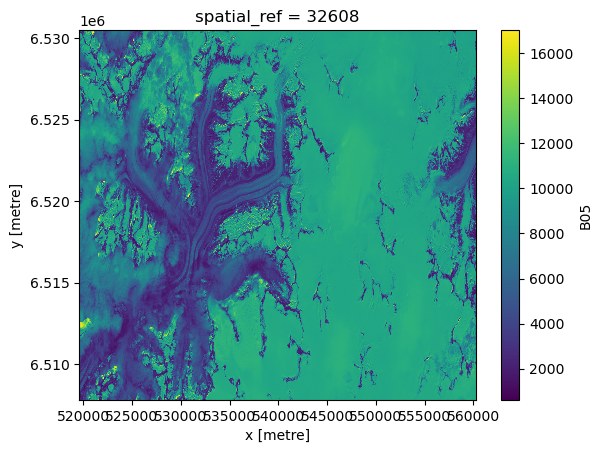

In [11]:
ds.B05.plot.imshow()